**Importation et nettoyage des données**

In [1]:
# Importez le jeu de données à l'aide de Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.0)

file_path = 'global_power_plant_database.csv'
data = pd.read_csv(file_path, low_memory=False)

print('Shape du jeu de données :', data.shape)
print('Colonnes disponibles :')
print(list(data.columns))

data.head()

Shape du jeu de données : (34936, 36)
Colonnes disponibles :
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [2]:
# Identifier les valeurs manquantes
missing_counts = data.isna().sum()
missing_percent = 100 * missing_counts / len(data)
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent
}).sort_values('missing_percent', ascending=False)

missing_summary.head(15)

,missing_count,missing_percent
other_fuel3,34844,99.736661
other_fuel2,34660,99.209984
other_fuel1,32992,94.435539
generation_gwh_2013,28519,81.632127
generation_gwh_2014,27710,79.316464
generation_gwh_2015,26733,76.519922
generation_gwh_2016,25792,73.826425
generation_gwh_2017,25436,72.807419
generation_gwh_2018,25299,72.415274
generation_gwh_2019,25277,72.352301


In [3]:
# Traiter les valeurs manquantes de manière appropriée
# Convertir les colonnes concernées en types numériques si nécessaire
numeric_cols = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year', 'year_of_capacity_data']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remplir ou clarifier les valeurs manquantes sur les colonnes textuelles importantes
data['primary_fuel'] = data['primary_fuel'].fillna('Unknown')

# Supprimer les lignes sans capacité connue, car l'analyse de puissance en dépend
clean_data = data.dropna(subset=['capacity_mw']).copy()

print('Données après nettoyage :', clean_data.shape)
clean_data[['capacity_mw', 'primary_fuel', 'country', 'commissioning_year']].head()

Données après nettoyage : (34936, 36)


,capacity_mw,primary_fuel,country,commissioning_year
0,33.0,Hydro,AFG,NaN
1,10.0,Solar,AFG,NaN
2,10.0,Solar,AFG,NaN
3,66.0,Hydro,AFG,NaN
4,100.0,Hydro,AFG,NaN


**Analyse exploratoire des données**

In [4]:
# Statistiques clés des principales colonnes numériques
numeric_summary = clean_data[['capacity_mw', 'latitude', 'longitude', 'commissioning_year', 'year_of_capacity_data']].describe().T
numeric_summary['median'] = clean_data[['capacity_mw', 'latitude', 'longitude', 'commissioning_year', 'year_of_capacity_data']].median()
numeric_summary['std_numpy'] = np.std(clean_data[['capacity_mw', 'latitude', 'longitude', 'commissioning_year', 'year_of_capacity_data']].values, axis=0, ddof=1)

numeric_summary[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'std_numpy']]

,count,mean,median,std,min,25%,50%,75%,max,std_numpy
capacity_mw,34936.0,163.355148,16.74500,489.636072,1.0000,4.900000,16.74500,75.344250,22500.0000,489.636072
latitude,34936.0,32.816637,39.72775,22.638603,-77.8470,29.256475,39.72775,46.263125,71.2920,22.638603
longitude,34936.0,-6.972803,-2.12710,78.405850,-179.9777,-77.641550,-2.12710,49.502675,179.3887,78.405850
commissioning_year,17447.0,1997.414823,2007.00000,23.397835,1896.0000,1988.000000,2007.00000,2014.000000,2020.0000,NaN
year_of_capacity_data,14887.0,2018.218849,2019.00000,1.606428,2000.0000,2017.000000,2019.00000,2019.000000,2019.0000,NaN


In [5]:
# Exploration de la répartition des centrales par pays et par type de combustible
country_counts = clean_data['country_long'].value_counts().head(15)
fuel_counts = clean_data['primary_fuel'].value_counts().head(15)

print('Top 15 pays par nombre de centrales :')
print(country_counts)
print('\nTop 15 types de combustibles :')
print(fuel_counts)

Top 15 pays par nombre de centrales :
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Japan                        522
Australia                    486
Portugal                     469
Czech Republic               462
Italy                        396
Name: count, dtype: int64

Top 15 types de combustibles :
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int

**Analyse statistique de la puissance de sortie par type de combustible**

In [6]:
# Entrée pour l'analyse statistique par type de carburant
fuel_stats = clean_data.groupby('primary_fuel')['capacity_mw'].agg([np.size, np.mean, np.median, np.std, np.min, np.max])
fuel_stats = fuel_stats.rename(columns={'size': 'count', 'std': 'std_dev'})
fuel_stats.sort_values('count', ascending=False).head(15)

,count,mean,median,std_dev,min,max
primary_fuel,,,,,,
Solar,10665,17.657039,5.80000,41.937445,1.0,1021.00
Hydro,7156,147.171551,20.00000,549.770911,1.0,22500.00
Wind,5344,49.224126,27.00000,106.128423,1.0,6000.00
Gas,3998,373.449375,147.50000,560.863990,1.0,8865.00
Coal,2330,843.579828,600.00000,887.996568,1.2,7000.00
Oil,2320,112.878754,9.00000,391.924545,1.0,6794.00
Biomass,1430,23.972938,9.45000,39.448004,1.0,528.00
Waste,1068,13.809657,4.80000,20.572864,1.0,160.90
Nuclear,195,2091.855179,1888.00000,1300.162646,20.0,8212.00


In [7]:
# Test d'hypothèses simple entre les deux combustibles principaux
major_fuels = clean_data['primary_fuel'].value_counts().index[:2].tolist()
print('Comparaison entre :', major_fuels)

fuel1 = clean_data.loc[clean_data['primary_fuel'] == major_fuels[0], 'capacity_mw'].values
fuel2 = clean_data.loc[clean_data['primary_fuel'] == major_fuels[1], 'capacity_mw'].values

mean1, mean2 = fuel1.mean(), fuel2.mean()
std1, std2 = fuel1.std(ddof=1), fuel2.std(ddof=1)
n1, n2 = len(fuel1), len(fuel2)

# Statistique t pour deux échantillons indépendants
se = np.sqrt(std1**2 / n1 + std2**2 / n2)
t_stat = (mean1 - mean2) / se

print(f'Moyenne {major_fuels[0]} = {mean1:.2f} MW, n={n1}')
print(f'Moyenne {major_fuels[1]} = {mean2:.2f} MW, n={n2}')
print(f'T-statistique approximative = {t_stat:.2f}')
print('Conclusion : les différences de moyenne sont importantes si |t| est élevé. Cela suggère une différence notable entre ces deux types de combustibles.')

Comparaison entre : ['Solar', 'Hydro']
Moyenne Solar = 17.66 MW, n=10665
Moyenne Hydro = 147.17 MW, n=7156
T-statistique approximative = -19.89
Conclusion : les différences de moyenne sont importantes si |t| est élevé. Cela suggère une différence notable entre ces deux types de combustibles.


**Analyse des séries chronologiques et évolution du mix énergétique**

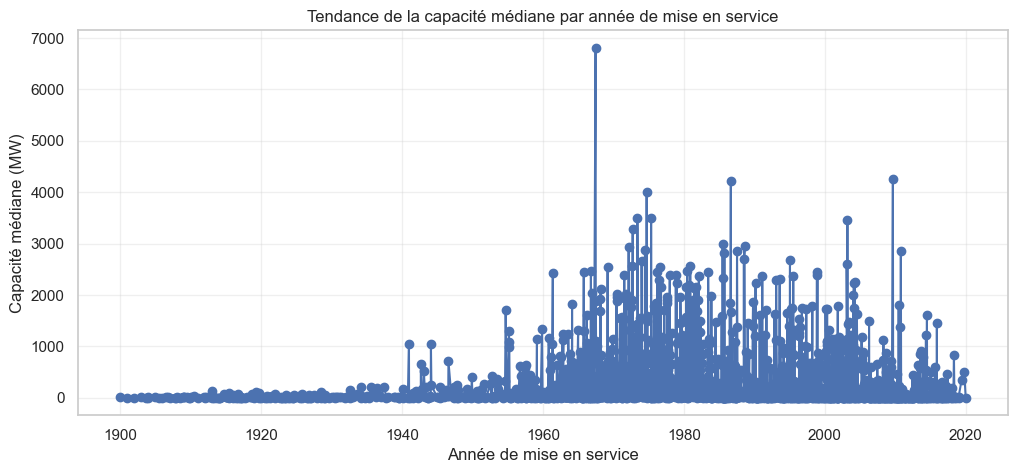

commissioning_year
1900.000000    6.50
1901.000000    3.70
1902.000000    1.50
1903.000000    9.85
1903.666667    3.00
Name: capacity_mw, dtype: float64

In [8]:
# Analyser les tendances par année de mise en service
year_data = clean_data[clean_data['commissioning_year'].between(1900, 2025)].copy()
trend_by_year = year_data.groupby('commissioning_year')['capacity_mw'].median()

plt.figure(figsize=(12, 5))
plt.plot(trend_by_year.index, trend_by_year.values, marker='o')
plt.title('Tendance de la capacité médiane par année de mise en service')
plt.xlabel('Année de mise en service')
plt.ylabel('Capacité médiane (MW)')
plt.grid(alpha=0.3)
plt.show()

trend_by_year.head()

<Figure size 1200x600 with 0 Axes>

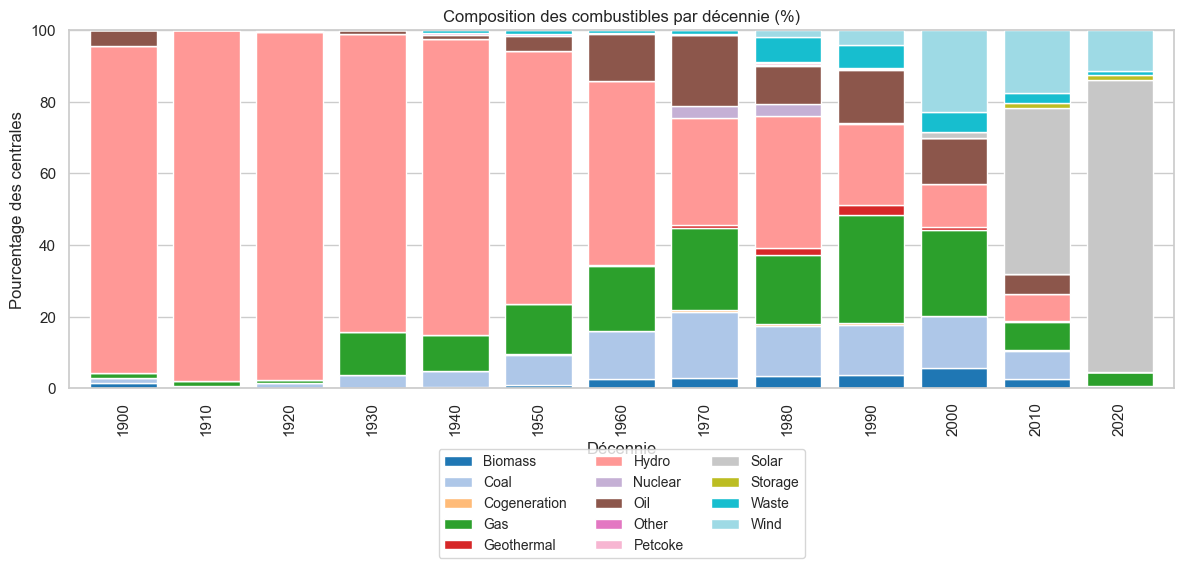

primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wind
decade,,,,,,,,,,,,,,
1930,0.00,3.70,0.00,12.17,0.00,83.07,0.00,1.06,0.00,0.00,0.00,0.00,0.00,0.00
1940,0.44,4.41,0.00,10.13,0.00,82.38,0.00,1.32,0.44,0.00,0.00,0.00,0.88,0.00
1950,0.91,8.35,0.36,13.79,0.00,70.78,0.00,3.99,0.54,0.18,0.00,0.00,1.09,0.00
1960,2.54,13.36,0.13,18.07,0.38,51.15,0.13,13.23,0.25,0.00,0.00,0.00,0.76,0.00
1970,2.94,18.49,0.32,23.11,0.74,29.73,3.57,19.75,0.00,0.21,0.00,0.00,1.05,0.11
1980,3.51,14.02,0.48,19.24,1.86,36.84,3.30,10.72,0.27,0.41,0.34,0.00,7.15,1.86
1990,3.69,14.13,0.49,30.16,2.58,22.79,0.31,14.80,0.25,0.12,0.12,0.00,6.27,4.30
2000,5.78,14.40,0.16,23.74,0.86,12.04,0.16,12.63,0.13,0.00,1.58,0.10,5.55,22.88
2010,2.68,7.80,0.10,7.89,0.43,7.31,0.06,5.54,0.11,0.00,46.28,1.37,2.85,17.58


In [9]:
# Comment la composition des types de combustibles évolue par décennie
year_data['decade'] = (year_data['commissioning_year'] // 10 * 10).astype('Int64')
composition = year_data.groupby(['decade', 'primary_fuel']).size().unstack(fill_value=0)
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
composition_pct.fillna(0).plot(kind='bar', stacked=True, width=0.8, figsize=(12, 6), colormap='tab20', legend=False)
plt.title('Composition des combustibles par décennie (%)')
plt.xlabel('Décennie')
plt.ylabel('Pourcentage des centrales')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small')
plt.tight_layout()
plt.show()

composition_pct.iloc[-10:].round(2)

**Visualisation avancée**

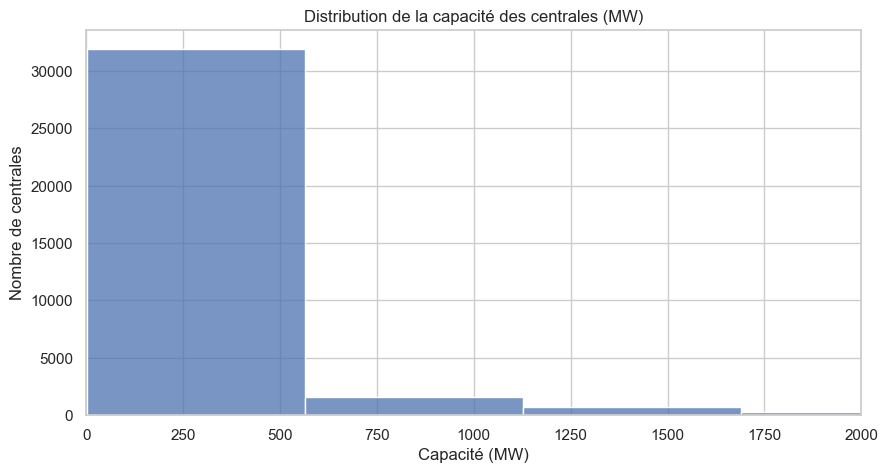

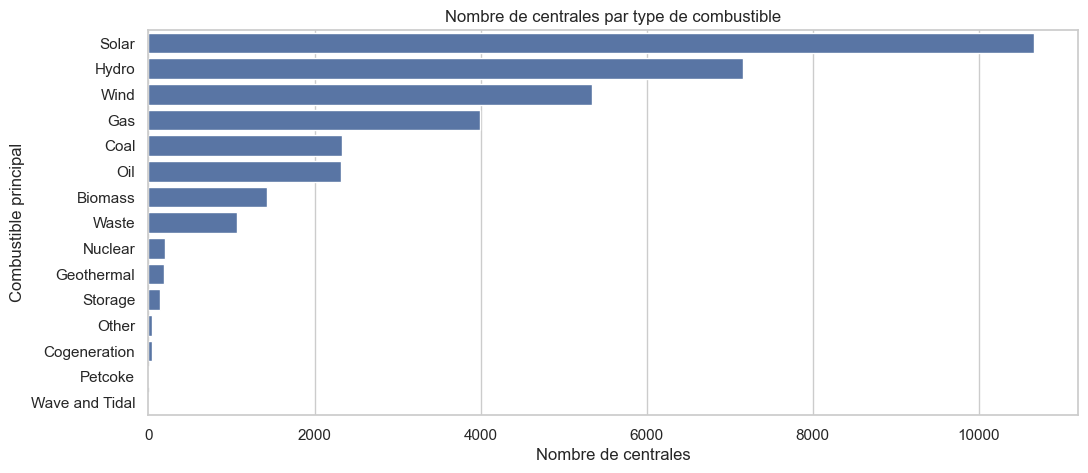

In [10]:
# Histogramme de la capacité et barplots de combustibles
plt.figure(figsize=(10, 5))
sns.histplot(clean_data['capacity_mw'], bins=40, kde=False)
plt.title('Distribution de la capacité des centrales (MW)')
plt.xlabel('Capacité (MW)')
plt.ylabel('Nombre de centrales')
plt.xlim(0, 2000)
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(data=clean_data, y='primary_fuel', order=fuel_counts.index)
plt.title('Nombre de centrales par type de combustible')
plt.xlabel('Nombre de centrales')
plt.ylabel('Combustible principal')
plt.show()

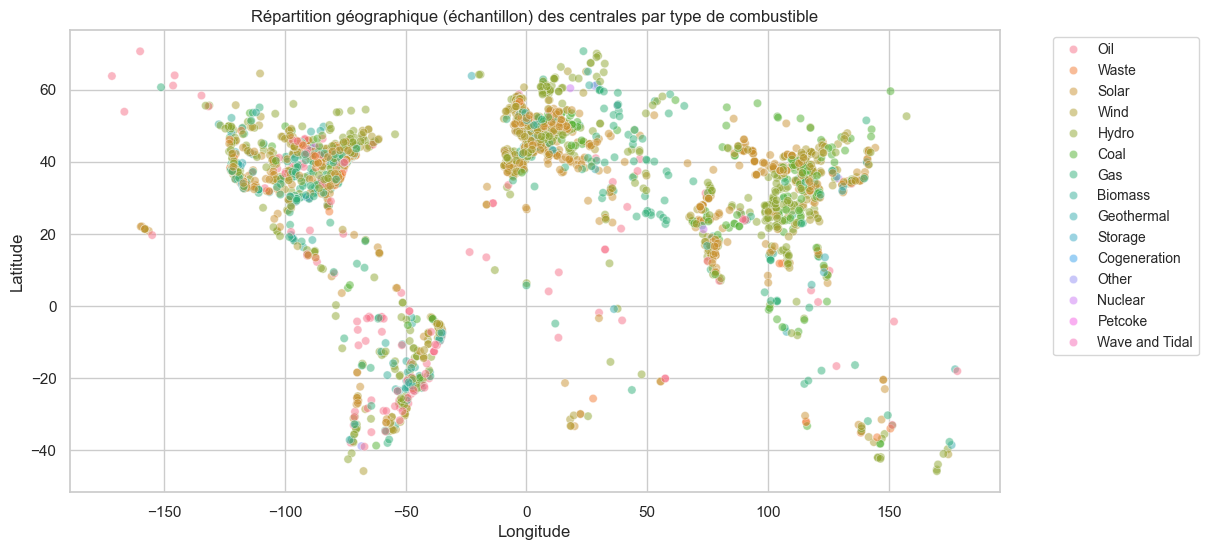

In [11]:
# Carte simple des centrales avec latitude et longitude
map_data = clean_data.dropna(subset=['latitude', 'longitude']).copy()
plt.figure(figsize=(12, 6))
sns.scatterplot(x='longitude', y='latitude', hue='primary_fuel', data=map_data.sample(min(3000, len(map_data)), random_state=42), legend='brief', alpha=0.5)
plt.title('Répartition géographique (échantillon) des centrales par type de combustible')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.show()

**Opérations matricielles en contexte réel**

In [12]:
# Matrice numérique et valeurs propres
matrix_cols = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']
numeric_matrix = clean_data.dropna(subset=matrix_cols)[matrix_cols].values
cov_matrix = np.cov(numeric_matrix, rowvar=False)
eigvals, eigvecs = np.linalg.eig(cov_matrix)

print('Matrice de covariance (4x4) :')
print(np.round(cov_matrix, 2))
print('\nValeurs propres :')
print(np.round(eigvals, 2))
print('\nVecteurs propres associés :')
print(np.round(eigvecs, 3))

Matrice de covariance (4x4) :
[[ 3.1154146e+05  1.0846000e+02  1.3727980e+04 -1.8162000e+02]
 [ 1.0846000e+02  4.5154000e+02 -1.5857000e+02 -7.5680000e+01]
 [ 1.3727980e+04 -1.5857000e+02  5.2394900e+03 -4.0130000e+01]
 [-1.8162000e+02 -7.5680000e+01 -4.0130000e+01  5.4746000e+02]]

Valeurs propres :
[312155.64   4632.04    403.94    588.34]

Vecteurs propres associés :
[[-0.999  0.045  0.002  0.001]
 [-0.     0.039 -0.88  -0.473]
 [-0.045 -0.998 -0.038 -0.012]
 [ 0.001  0.007 -0.473  0.881]]


Les valeurs propres indiquent les directions de variation maximale des données numériques. Les vecteurs propres correspondent aux combinaisons linéaires des attributs (capacité, latitude, longitude, année) qui expliquent le plus de variance.

In [13]:
# Exemple d'utilisation de NumPy pour un filtrage complexe dans Pandas
cond = (
    (clean_data['capacity_mw'].values > 200) &
    (clean_data['commissioning_year'].values >= 2000) &
    (clean_data['primary_fuel'].isin(['Coal', 'Gas', 'Hydro']).values)
)
selected = clean_data.loc[cond, ['name', 'country_long', 'primary_fuel', 'capacity_mw', 'commissioning_year']]
selected.head(10)

,name,country_long,primary_fuel,capacity_mw,commissioning_year
27,Arbaa,Algeria,Gas,560.0,2010.0
30,Boufarik 2,Algeria,Gas,450.0,2016.0
31,Boutelilis,Algeria,Gas,450.0,2016.0
36,Hadjret Ennous,Algeria,Gas,1200.0,2009.0
39,Hassi Messoud,Algeria,Gas,600.0,2015.0
49,Koudiet Eddraouch,Algeria,Gas,1200.0,2013.0
51,Labreg,Algeria,Gas,396.0,2015.0
62,Relizane,Algeria,Gas,465.0,2010.0
63,SKB IPP,Algeria,Gas,484.0,2007.0
64,SKS IPP SNC Lavalin,Algeria,Gas,815.0,2006.0


**Conclusion**

- Le jeu de données contient des informations sur plus de 34 000 centrales électriques.
- Le nettoyage a converti les colonnes numériques et traité les valeurs manquantes critiques.
- L'analyse montre la répartition par pays, par type de combustible et la puissance moyenne par carburant.
- La série temporelle et la composition par décennie permettent d'observer l'évolution du mix énergétique.
- Les opérations matricielles avec NumPy sont utiles pour comprendre les relations entre capacité, localisation et année de mise en service.